In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import os
os.chdir("/disk/u/gio/mechinterp-1")

In [6]:
from source.analysis import collect_activations, activation_patch

/disk/u/gio/.conda/envs/retrieval2/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [7]:
from nnsight import LanguageModel

model = LanguageModel("meta-llama/Meta-Llama-3.1-8B")

In [ ]:
import torch
from source.analysis import Prediction
from typing import Literal

def logit_lens(
    model: LanguageModel,
    prompt: str,
    kind: Literal["full", "last"] = "last",
    k: int = 5,
    return_logits: bool = False
):
    """ Warning: Only supports llama models! """

    logit_lens = []
    num_layers = model.config.num_hidden_layers

    if kind == "last":
        logits_probs = []
        with torch.no_grad():
            with model.trace(prompt):
                logits = model.output.logits[0].save()
                probs = logits.softmax(dim=-1).save()
                logits_probs.append((logits, probs))
        logits = logits_probs[0][0][-1].topk(k=k).values
        probs = logits_probs[0][1][-1].topk(k=k).values
        token_ids = logits_probs[0][1][-1].topk(k=k).indices
        tokens = [model.tokenizer.decode(id) for id in token_ids]

        for t, l, p, id in zip(tokens, logits, probs, token_ids):
            prediction = Prediction(
                token_str=t,
                token_id=id.item(),
                prob=round(p.item(), 6),
                logit=round(l.item(), 6)
            )
            logit_lens.append(prediction)

        return logit_lens
    
    elif kind == "full":

        layer_logits = []

        with torch.no_grad():
            with model.trace(prompt):
                for layer in model.model.layers:
                    # residual stream at this layer
                    h = layer.output[0]
                    h_ln = model.model.norm(h)
                    logits = model.lm_head(h_ln).save()
                    layer_logits.append(logits)

        results = {i: [] for i in range(num_layers)}
        for li, logits in enumerate(layer_logits):
            last = logits[-1]
            topk = last.topk(k=k)
            ids = topk.indices
            toks = [model.tokenizer.decode(int(i)) for i in ids]
            probs = last.softmax(dim=-1)[ids]
            for rank, (t, i, p, l) in enumerate(zip(toks, ids, probs, topk.values), start=1):
                results[li].append(f'{rank}. "{t}"[{int(i)}] (p={float(p):.6f}, logit={float(l):.6f})')

        return results
        

In [13]:
logit_lens(
    model,
    "The cup is located on the table. The jar is sitting on the chair. Cup is to jar as table is to",
)[0].token_id

10716

In [ ]:
for prompt in p

In [26]:
logit_lens(
    model,
    "The cup is located on the table. The cup is full of coffee. The jar is sitting on the chair. The jar is brimming with tea. Cup is to jar as table is to",
)

['" chair"[10716] (p=0.4975174069404602, logit=18.53453254699707)',
 '" ______"[33771] (p=0.0882176011800766, logit=16.80470848083496)',
 '" _____"[66992] (p=0.053841546177864075, logit=16.31094741821289)',
 '" __"[1328] (p=0.041396550834178925, logit=16.048099517822266)',
 '" ____"[31843] (p=0.034092195332050323, logit=15.853970527648926)']

In [27]:
logit_lens(
    model,
    "The cup is located on the table. The cup is full of coffee. The cup is colored yellow. The jar is sitting on the chair. The jar is brimming with tea. The jar is painted blue. Cup is to jar as table is to",
)

['" chair"[10716] (p=0.6255626678466797, logit=18.88088607788086)',
 '" ______"[33771] (p=0.04430954530835152, logit=16.233434677124023)',
 '" _____"[66992] (p=0.03860849514603615, logit=16.095706939697266)',
 '"."[662] (p=0.033789873123168945, logit=15.962395668029785)',
 '"."[13] (p=0.03334764018654823, logit=15.94922161102295)']

In [ ]:
logit_lens(
    model,
    "The cup is located on the table. The cup is full of coffee. The cup is colored yellow. The jar is sitting on the chair. The jar is brimming with tea. The jar is painted blue. Cup is to jar as table is to",
)

In [9]:
import json

data = []
with open('data_save/relation_selection_dataset_v2.jsonl', 'r') as f:
    for line in f:
        data.append(json.loads(line))

In [7]:
data

[{'story': 'The sculpture is crafted out of clay. The vase is housed in the park. The sculpture is inside the gallery. The vase is made of marble.',
  'prompt': '',
  'analogy': 'vase is to marble as sculpture is to',
  'answer': 'clay',
  'meta': {'relation_target': 'made of',
   'relation_distractor_family': 'located in',
   'surface_r1_s1': 'made of',
   'surface_r1_s2': 'crafted out of',
   'surface_r2_s1': 'housed in',
   'surface_r2_s2': 'inside',
   'r1_synonyms_distinct': True,
   'sentences_shuffled': True,
   'lexicon_condition': 'real',
   's1_noun_type': 'real',
   's2_noun_type': 'real',
   'seed': 23,
   'template': 'S1:O1::S2:?',
   'task': 'Task-2 (S→O)'}},
 {'story': 'The statue is resting on the shelf. The jar is perched on the table. The jar is made of bronze. The statue is constructed from glass.',
  'prompt': '',
  'analogy': 'bronze is to jar as glass is to',
  'answer': 'statue',
  'meta': {'relation_target': 'made of',
   'relation_distractor_family': 'rests on'

In [ ]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

results = {
    "Success": 0,
    "Failure": 0
}
counter = 0

for sample in tqdm(data):
    pred = logit_lens(model, [sample['story'] + sample['analogy']])

    if sample['answer'].startswith(pred[0].token_str.strip()):
        results['Success'] += 1
    else:
        results['Failure'] += 1

    counter +=1

    if counter % 10 == 0:
        print(f"{results=}")
    
plt.figure(figsize=(8,8))
plt.bar(
    x=results.keys(),
    height=results.values()
)

  0%|          | 0/1200 [00:00<?, ?it/s]

results={'Success': 10, 'Failure': 0}
results={'Success': 18, 'Failure': 2}
results={'Success': 27, 'Failure': 3}
results={'Success': 36, 'Failure': 4}
results={'Success': 45, 'Failure': 5}
results={'Success': 54, 'Failure': 6}
results={'Success': 63, 'Failure': 7}
results={'Success': 73, 'Failure': 7}
results={'Success': 82, 'Failure': 8}
results={'Success': 92, 'Failure': 8}
results={'Success': 100, 'Failure': 10}
results={'Success': 109, 'Failure': 11}
results={'Success': 117, 'Failure': 13}
results={'Success': 126, 'Failure': 14}
results={'Success': 136, 'Failure': 14}
results={'Success': 145, 'Failure': 15}
results={'Success': 155, 'Failure': 15}
results={'Success': 164, 'Failure': 16}
results={'Success': 172, 'Failure': 18}
results={'Success': 181, 'Failure': 19}
results={'Success': 190, 'Failure': 20}
results={'Success': 199, 'Failure': 21}
results={'Success': 209, 'Failure': 21}
results={'Success': 216, 'Failure': 24}
results={'Success': 226, 'Failure': 24}
results={'Success': 

KeyboardInterrupt: 

In [6]:
clean_prompt = "Mary had a little"
patch_prompt = "Santa had a little"

patch_activations = collect_activations(
    model=model,
    prompt=patch_prompt,
)

In [7]:
model.config.architectures[0]

'LlamaForCausalLM'

In [8]:
from source.probing import Probe

In [16]:
lamb_vs_not_lamb = {
    "lamb": [
        "The lamb jumped over the fence.",
        "She cradled the lamb in her arms.",
        "A lamb was born on the farm last night.",
        "He roasted a leg of lamb for dinner.",
        "The shepherd counted his lambs before sleeping.",
        "The lamb bleated softly as it searched for its mother.",
        "Mary had a little lamb, its fleece was white as snow.",
        "Wolves prey on stray lambs in the wild.",
        "They spotted a lone lamb in the meadow.",
        "A gentle lamb wandered into the village.",
        "A newborn lamb took its first steps in the barn.",
        "The lamb's wool was soft and freshly sheared.",
        "She bottle-fed the orphaned lamb every morning.",
        "They watched the lamb leap through the tall grass.",
        "The lamb followed the shepherd closely.",
        "Snowflakes landed on the lamb's fleece.",
        "The lamb stood trembling in the cold wind.",
        "He spotted a lost lamb on the hillside.",
        "The lamb nibbled on wildflowers in the meadow.",
        "A frightened lamb bleated from behind a tree.",
        "The lamb was named Daisy by the children.",
        "The mother ewe nudged her lamb gently.",
        "Sunlight filtered through the barn onto the lamb.",
        "The lamb's hooves clicked softly on the wooden floor.",
        "She wrote a poem about a lamb she once raised.",
        "The veterinarian checked the lamb's heartbeat.",
        "The lamb curled up beside the stove.",
        "The villagers celebrated the birth of the lamb.",
        "He drew a picture of a lamb in his notebook.",
        "They led the lamb away from the muddy ditch.",
        "The lamb drank milk from a silver bowl.",
        "A lamb wandered too far and got stuck in a fence.",
        "The lamb's ear twitched at the sound of thunder.",
        "He carried the lamb through the snowstorm.",
        "The lamb was dyed pink for the festival.",
        "They examined the fossils in the museum.",
        "The frog croaked near the pond.",
        "He scribbled notes in the margin.",
        "She climbed into the treehouse.",
        "The turtle hid in its shell.",
        "They discussed philosophy over coffee.",
        "The rooster strutted through the yard.",
        "She downloaded a new app on her phone.",
        "The camel trudged through the desert.",
        "He admired the sculpture in silence.",
        "The hawk circled above the forest."
    ],
    "not-lamb": [
        "The cat jumped over the fence.",
        "She cradled the baby in her arms.",
        "A cow was born on the farm last night.",
        "He roasted a chicken for dinner.",
        "The shepherd counted his goats before sleeping.",
        "The dog barked loudly as it searched for its owner.",
        "Mary had a little dog, its tail wagged happily.",
        "Wolves prey on stray deer in the wild.",
        "They spotted a lone fox in the meadow.",
        "A gentle breeze wandered into the village.",
        "The train arrived ten minutes late.",
        "She opened the book and began to read.",
        "He spilled coffee on the report before the meeting.",
        "They watched the sunset from the balcony.",
        "The computer crashed before she could save her work.",
        "I forgot my umbrella and got soaked in the rain.",
        "He played the piano with remarkable emotion.",
        "The smell of fresh bread filled the kitchen.",
        "She packed her suitcase for the weekend trip.",
        "We waited in line for concert tickets.",
        "Hope is the thing with feathers.",
        "Justice must be served without delay.",
        "The idea spread like wildfire online.",
        "Love can be both a gift and a burden.",
        "Curiosity drove him to explore the unknown.",
        "Truth is often stranger than fiction.",
        "The silence in the room was deafening.",
        "Dreams faded with the morning light.",
        "He questioned the meaning of his actions.",
        "Time moves differently in moments of crisis.",
        "The dog barked at the passing car.",
        "She poured coffee into a chipped mug.",
        "A fox darted across the empty road.",
        "He found a lost kitten under the porch.",
        "The baby giggled at the funny noise.",
        "They danced under the pale moonlight.",
        "The teacher wrote equations on the board.",
        "The goat chewed on a cardboard box.",
        "A rabbit hopped through the garden silently.",
        "The wind rustled the pages of the open book.",
        "He fixed the broken radio with a paperclip.",
        "They baked bread early in the morning.",
        "The cow mooed loudly near the gate.",
        "She packed a suitcase and left at dawn.",
        "The horse galloped through the valley.",
        "He watched the documentary about space travel.",
        "A pigeon landed on the windowsill.",
        "The toddler scribbled on the wall.",
        "She found a seashell buried in the sand.",
        "The engineer presented his new design.",
        "A snake slithered past the log.",
        "They climbed the stairs to the rooftop.",
        "The artist painted abstract shapes in blue.",
        "He listened to jazz as he cooked dinner.",
        "The penguin slid across the icy slope.",
        "The deer froze when it heard a twig snap.",
        "She polished the antique vase carefully.",
        "The fish swam in circles inside the bowl.",
        "He wrote a letter to his grandmother.",
        "The elephant sprayed water on its back.",
        "They recited poetry around the campfire.",
        "The squirrel gathered acorns before winter.",
        "She braided her sister's hair.",
        "The dolphin jumped through the hoop.",
        "He swept the floor before guests arrived.",
        "The owl blinked in the sunlight.",
        "The hikers stopped to drink from the stream.",
        "She folded the laundry neatly.",
        "The spider spun a web in the corner.",
        "He tossed a coin into the fountain.",
        "The parrot mimicked their laughter.",
        "They played chess by candlelight.",
        "The bear sniffed the air cautiously.",
        "She opened the window to let in fresh air.",
        "The rooster crowed at dawn.",
        "He replaced the batteries in the remote.",
        "The cat stretched out on the windowsill.",
        "She hummed while chopping vegetables.",
        "A crane stood alone in the rice field.",
        "They examined the fossils in the museum.",
        "The frog croaked near the pond.",
        "He scribbled notes in the margin.",
        "She climbed into the treehouse.",
        "The turtle hid in its shell.",
        "They discussed philosophy over coffee.",
        "The rooster strutted through the yard.",
        "She downloaded a new app on her phone.",
        "The camel trudged through the desert.",
        "He admired the sculpture in silence.",
        "The hawk circled above the forest."
    ]
}

In [17]:
lamb_probe = Probe(
    positive_samples=lamb_vs_not_lamb['lamb'],
    negative_samples=lamb_vs_not_lamb['not-lamb'],
    model=model
)

print(f"Probe initialized for {lamb_probe.n_layers} layers.")
print(f"Training set size: {len(lamb_probe.train_idx)}")
print(f"Test set size: {len(lamb_probe.test_idx)}")

Probe initialized for 32 layers.
Training set size: 108
Test set size: 28


In [18]:
lamb_probe.train()

Activation collection complete.
Training probes for each layer...
Training complete.
Evaluating probes...
Layer 0: AUC = 0.775
Layer 1: AUC = 0.705
Layer 2: AUC = 0.722
Layer 3: AUC = 0.716
Layer 4: AUC = 0.693
Layer 5: AUC = 0.681
Layer 6: AUC = 0.711
Layer 7: AUC = 0.716
Layer 8: AUC = 0.705
Layer 9: AUC = 0.693
Layer 10: AUC = 0.693
Layer 11: AUC = 0.711
Layer 12: AUC = 0.705
Layer 13: AUC = 0.705
Layer 14: AUC = 0.693
Layer 15: AUC = 0.699
Layer 16: AUC = 0.711
Layer 17: AUC = 0.705
Layer 18: AUC = 0.728
Layer 19: AUC = 0.751
Layer 20: AUC = 0.740
Layer 21: AUC = 0.757
Layer 22: AUC = 0.757
Layer 23: AUC = 0.740
Layer 24: AUC = 0.740
Layer 25: AUC = 0.751
Layer 26: AUC = 0.751
Layer 27: AUC = 0.751
Layer 28: AUC = 0.757
Layer 29: AUC = 0.763
Layer 30: AUC = 0.775
Layer 31: AUC = 0.798


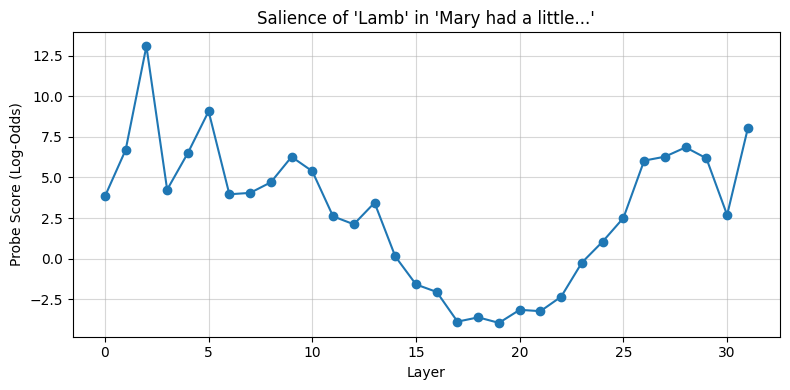

In [19]:
# Score a prompt where "lamb" is the likely next word
prompt1 = "The popular nursery rhyme 'Mary had a little"
scores1 = lamb_probe.score_by_layer(prompt1)

# The scores are stored in the instance, so you can plot them directly
lamb_probe.plot_layer_scores(title="Salience of 'Lamb' in 'Mary had a little...'")

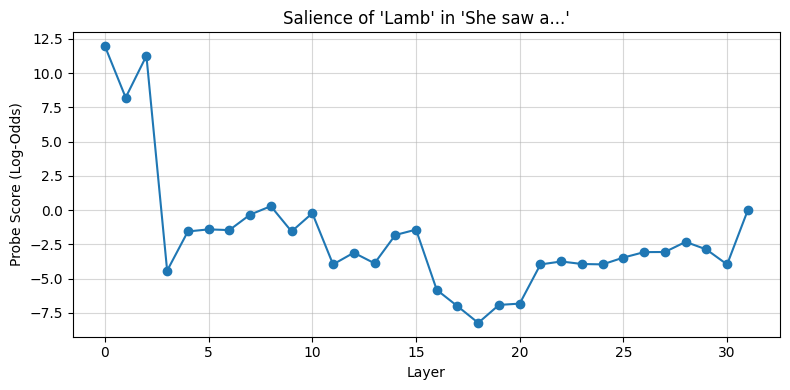

In [20]:
# Score a more neutral prompt
prompt2 = "She walked through the field and saw a"
scores2 = lamb_probe.score_by_layer(prompt2)
lamb_probe.plot_layer_scores(title="Salience of 'Lamb' in 'She saw a...'")

In [21]:
# 1. Score three related prompts
s_neutral = lamb_probe.score_by_layer("Mary had a little")
s_control = lamb_probe.score_by_layer("Mary had a little lamb")
s_contrast = lamb_probe.score_by_layer("Mary had a little dog")

# 2. Calculate the deltas
delta_pos = s_control - s_neutral  # How much does adding "lamb" increase the score?
delta_neg = s_neutral - s_contrast # How much more "lamb-like" is the neutral prompt than the "dog" prompt?

# 3. Plot the deltas to see where the concept is most affected
plt.figure(figsize=(10, 4))

# Plot positive delta
plt.subplot(1, 2, 1)
plt.plot(np.arange(len(delta_pos)), delta_pos, marker="o", color='green')
plt.xlabel("Layer")
plt.ylabel("Score Increase")
plt.title("Effect of adding 'lamb'")
plt.grid(True, alpha=0.5)

# Plot negative delta
plt.subplot(1, 2, 2)
plt.plot(np.arange(len(delta_neg)), delta_neg, marker="o", color='red')
plt.xlabel("Layer")
plt.ylabel("Score Difference")
plt.title("'little' vs 'little dog'")
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined